# Results table — STGCN & PoseC3D across energy targets (this project's trained models)

Models are trained on **Watts/kg** targets (`build_method_pkls.py` from `AbleBody2_full.pkl`), 24 epochs each.

For each run: among the **epoch 22–24** checkpoints, pick the lowest val-MAE one, then evaluate it on the
**test** split. (Epoch window is fixed so every model is reported at a comparable late checkpoint rather than an
early cherry-picked one — note PoseC3D's val curve is unstable, so its epoch 22–24 numbers are worse than its
earlier dips; see `overfitting_check.png`.) Watts metrics scale pred and label by each subject's `weight` (kg).
Schema: Model / Experiment / Units / Epoch / TestSamples / MSE / MAE / RMSE / Pearson r / R2.
GCNHead / I3DHead need `test_cfg=dict(average_clips='score')`.

In [1]:
import os, glob, warnings
import numpy as np, pandas as pd, torch
from copy import deepcopy
from mmcv import Config
from mmcv.runner import load_checkpoint
from pyskl.models import build_model
from pyskl.datasets import build_dataset, build_dataloader
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EXP_LABEL = {'nearest': 'Nearest EE', 'exact': 'Exact Windowing', 'windowing': 'Windowing Avg Drop'}


def build_eval_loader(cfg, split, spg=8):
    """Deterministic (num_clips=1) loader for any split, from the cfg.data.val template."""
    ds_cfg = deepcopy(cfg.data.val)
    ds_cfg['type'] = ds_cfg.get('type', 'PoseDataset')
    ds_cfg['split'] = split
    ds_cfg['test_mode'] = True
    dataset = build_dataset(ds_cfg, dict(test_mode=True))
    loader = build_dataloader(dataset, videos_per_gpu=spg, workers_per_gpu=2, shuffle=False)
    return loader


def weights_for(loader):
    """Per-sample body weight (kg), aligned to loader order (shuffle=False)."""
    return np.array([vi.get('weight', np.nan) for vi in loader.dataset.video_infos], dtype=float)


@torch.no_grad()
def run_inference(model, loader):
    preds, labels = [], []
    for batch in loader:
        y = batch['label'].numpy().reshape(-1)
        if 'imgs' in batch:                       # PoseC3D
            out = model(batch['imgs'].to(DEVICE), return_loss=False)
        else:                                     # GCN
            out = model(batch['keypoint'].to(DEVICE), return_loss=False)
        p = np.asarray(out).reshape(len(y), -1).mean(axis=1)
        preds.append(p); labels.append(y)
    return np.concatenate(preds), np.concatenate(labels)


def metrics(p, y):
    e = p - y
    ss_res = np.sum(e ** 2); ss_tot = np.sum((y - y.mean()) ** 2)
    mse = float(np.mean(e ** 2))
    return dict(MAE=float(np.mean(np.abs(e))), MSE=mse, RMSE=float(np.sqrt(mse)),
                MRE=float(np.mean(np.abs(e) / np.abs(y))),
                r=float(np.corrcoef(p, y)[0, 1]), R2=float(1 - ss_res / ss_tot))


def epoch_ckpts(work_dir):
    fs = glob.glob(os.path.join(work_dir, 'epoch_*.pth'))
    return sorted(fs, key=lambda f: int(os.path.basename(f).split('epoch_')[1].split('.pth')[0]))


def ep_num(ck):
    return int(os.path.basename(ck).split('epoch_')[1].split('.pth')[0])

/home/students/mmasabo1/miniconda3/envs/pyskl_310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/students/mmasabo1/miniconda3/envs/pyskl_310/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


In [2]:
RUNS = [
    dict(model='STGCN', method='nearest',
         config='configs/stgcn/ablebody2_wattkg/nearest.py',
         work_dir='work_dirs/stgcn/ablebody2_wattkg/nearest'),
    dict(model='STGCN', method='exact',
         config='configs/stgcn/ablebody2_wattkg/exact.py',
         work_dir='work_dirs/stgcn/ablebody2_wattkg/exact'),
    dict(model='STGCN', method='windowing',
         config='configs/stgcn/ablebody2_wattkg/windowing.py',
         work_dir='work_dirs/stgcn/ablebody2_wattkg/windowing'),
    dict(model='PoseC3D', method='nearest',
         config='configs/posec3d/ablebody2_wattkg/nearest.py',
         work_dir='work_dirs/posec3d/ablebody2_wattkg/nearest'),
    dict(model='PoseC3D', method='exact',
         config='configs/posec3d/ablebody2_wattkg/exact.py',
         work_dir='work_dirs/posec3d/ablebody2_wattkg/exact'),
    dict(model='PoseC3D', method='windowing',
         config='configs/posec3d/ablebody2_wattkg/windowing.py',
         work_dir='work_dirs/posec3d/ablebody2_wattkg/windowing'),
]


In [3]:
schema_rows, detail_rows, cache = [], [], {}

EPOCH_WINDOW = (22, 24)   # report each model at a comparable late epoch, not an early cherry-picked one

for run in RUNS:
    tag = f"{run['model']}/{run['method']}"
    cks = [ck for ck in epoch_ckpts(run['work_dir'])
           if EPOCH_WINDOW[0] <= ep_num(ck) <= EPOCH_WINDOW[1]]
    if not cks:
        print(f'SKIP {tag}: no epoch_{EPOCH_WINDOW[0]}..{EPOCH_WINDOW[1]}.pth in {run["work_dir"]}')
        continue

    cfg = Config.fromfile(run['config'])
    model = build_model(cfg.model).to(DEVICE).eval()

    # --- best epoch by val MAE within the epoch window (W/kg) ---
    val_loader = build_eval_loader(cfg, 'val')
    best = None
    for ck in cks:
        load_checkpoint(model, ck, map_location='cpu'); model.eval()
        p, y = run_inference(model, val_loader)
        vmae = float(np.mean(np.abs(p - y)))
        print(f'{tag}  epoch {ep_num(ck):2d}  val MAE {vmae:.4f}')
        if best is None or vmae < best[1]:
            best = (ck, vmae)
    best_ck, best_ep = best[0], ep_num(best[0])
    load_checkpoint(model, best_ck, map_location='cpu'); model.eval()
    print(f'--> {tag} reported epoch = {best_ep} (val MAE {best[1]:.4f})\n')

    # --- detailed train/val/test in W/kg ---
    for split in ['train', 'val', 'test']:
        ld = build_eval_loader(cfg, split)
        p, y = run_inference(model, ld)
        cache[(run['model'], run['method'], split)] = (p, y)
        m = metrics(p, y)
        detail_rows.append(dict(Model=run['model'], Experiment=EXP_LABEL[run['method']],
                                Split=split, Epoch=best_ep, N=len(y),
                                MAE=m['MAE'], MSE=m['MSE'], RMSE=m['RMSE'],
                                MRE=m['MRE'], r=m['r'], R2=m['R2']))

    # --- test split in both units (schema table) ---
    test_loader = build_eval_loader(cfg, 'test')
    p, y = run_inference(model, test_loader)
    w = weights_for(test_loader)
    units = [('W/kg', p, y)]
    if np.isfinite(w).all():
        units.append(('Watts', p * w, y * w))
    else:
        print(f'{tag}: some weights missing — skipping Watts row')
    for uname, pp, yy in units:
        m = metrics(pp, yy)
        schema_rows.append({'Model': run['model'], 'Experiment': EXP_LABEL[run['method']],
                            'Units': uname, 'Epoch': best_ep, 'TestSamples': len(yy),
                            'MAE': m['MAE'], 'MSE': m['MSE'], 'RMSE': m['RMSE'],
                            'Pearson r': m['r'], 'R2': m['R2']})

schema = pd.DataFrame(schema_rows, columns=['Model', 'Experiment', 'Units', 'Epoch',
                                            'TestSamples', 'MAE', 'MSE', 'RMSE', 'Pearson r', 'R2'])
detail = pd.DataFrame(detail_rows)
print('done' if schema_rows else 'no results — train first: bash train_wattkg_stgcn.sh')



DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_wattkg/nearest.pkl
split: val
valid_ratio parameter: None
box_thr parameter: None


2026-09-05 12:17:13,457 - pyskl - INFO - 582 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 582
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 582
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 582

load checkpoint from local path: work_dirs/stgcn/ablebody2_wattkg/nearest/epoch_22.pth
STGCN/nearest  epoch 22  val MAE 0.4112
load checkpoint from local path: work_dirs/stgcn/ablebody2_wattkg/nearest/epoch_23.pth
STGCN/nearest  epoch

2026-09-05 12:17:16,701 - pyskl - INFO - 4710 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 4710
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 4710
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 4710


DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_wattkg/nearest.pkl
split: val
valid_ratio parameter: None
box_thr parameter: None


...


After super().__init__():
  len(self.video_infos): 582
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 582
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 582


DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_wattkg/windowing.pkl
split: test
valid_ratio parameter: None
box_thr parameter: None


2026-09-05 12:21:43,601 - pyskl - INFO - 579 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 579
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 579
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 579


DEBUG PoseDataset.__init__
ann_file: /home/students/mmasabo1/summer26Research/ablebody2_wattkg/windowing.pkl
split: test
valid_ratio parameter: None
box_thr parameter: None


2026-09-05 12:21:50,019 - pyskl - INFO - 579 videos remain after valid thresholding



After super().__init__():
  len(self.video_infos): 579
  First sample keys: ['frame_dir', 'label', 'img_shape', 'total_frames', 'num_person_raw', 'keypoint', 'keypoint_score', 'name', 'file_number', 'gait', 'modality', 'age', 'gender', 'height', 'weight', 'watts', 'energy_cal', 'nearest_ee_watts', 'exact_windowing_energy_watts', 'windowing_drop_avg_energy_watts', 'heart_rate', 'exact_windowing_hr', 'windowing_drop_avg_hr', 'vo2_per_kg', 'rer', 've_stpd', 'mets', 'vo2_stpd', 'vco2_stpd']
  First sample 'total_frames': 299

Before valid_ratio filtering:
  self.valid_ratio: None
  type(self.valid_ratio): <class 'NoneType'>
  len(self.video_infos): 579
  Will filtering run? False
  ✓ Filtering is DISABLED (valid_ratio=None)

FINAL len(self.video_infos): 579

done


In [4]:
# Project-format table (test split, both units)
if len(schema):
    schema.to_csv('evaluation_results_trained.csv', index=False)
    with pd.option_context('display.float_format', lambda x: f'{x:.6f}'):
        print(schema.to_string(index=False))
    print('\nsaved -> evaluation_results_trained.csv')
schema

  Model         Experiment Units  Epoch  TestSamples       MAE         MSE      RMSE  Pearson r       R2
  STGCN         Nearest EE  W/kg     24          582  0.414318    0.290963  0.539410   0.945354 0.892036
  STGCN         Nearest EE Watts     24          582 34.390349 2086.226048 45.675224   0.955193 0.910986
  STGCN    Exact Windowing  W/kg     22          582  0.373373    0.240512  0.490420   0.955535 0.909056
  STGCN    Exact Windowing Watts     22          582 31.195332 1766.843195 42.033834   0.962614 0.923382
  STGCN Windowing Avg Drop  W/kg     22          579  0.382402    0.254575  0.504554   0.953521 0.904387
  STGCN Windowing Avg Drop Watts     22          579 31.972324 1867.528937 43.214916   0.960931 0.919453
PoseC3D         Nearest EE  W/kg     23          582  0.907303    1.148412  1.071640   0.941458 0.573873
PoseC3D         Nearest EE Watts     23          582 74.640260 8090.273393 89.945947   0.951285 0.654808
PoseC3D    Exact Windowing  W/kg     23          582  1

,Model,Experiment,Units,Epoch,TestSamples,MAE,MSE,RMSE,Pearson r,R2
0,STGCN,Nearest EE,W/kg,24,582,0.414318,0.290963,0.539410,0.945354,0.892036
1,STGCN,Nearest EE,Watts,24,582,34.390349,2086.226048,45.675224,0.955193,0.910986
2,STGCN,Exact Windowing,W/kg,22,582,0.373373,0.240512,0.490420,0.955535,0.909056
3,STGCN,Exact Windowing,Watts,22,582,31.195332,1766.843195,42.033834,0.962614,0.923382
4,STGCN,Windowing Avg Drop,W/kg,22,579,0.382402,0.254575,0.504554,0.953521,0.904387
5,STGCN,Windowing Avg Drop,Watts,22,579,31.972324,1867.528937,43.214916,0.960931,0.919453
6,PoseC3D,Nearest EE,W/kg,23,582,0.907303,1.148412,1.071640,0.941458,0.573873
7,PoseC3D,Nearest EE,Watts,23,582,74.640260,8090.273393,89.945947,0.951285,0.654808
8,PoseC3D,Exact Windowing,W/kg,23,582,1.024954,1.386298,1.177412,0.953078,0.475803
9,PoseC3D,Exact Windowing,Watts,23,582,84.034086,9622.094038,98.092273,0.961918,0.582742


In [5]:
# Detailed train/val/test breakdown (W/kg)
if len(detail):
    detail.to_csv('evaluation_results_trained_detail.csv', index=False)
    with pd.option_context('display.float_format', lambda x: f'{x:.4f}'):
        print(detail.to_string(index=False))
detail

  Model         Experiment Split  Epoch    N    MAE    MSE   RMSE    MRE      r     R2
  STGCN         Nearest EE train     24 4710 0.3864 0.2992 0.5470 0.0928 0.9434 0.8892
  STGCN         Nearest EE   val     24  582 0.4060 0.3001 0.5479 0.0879 0.9427 0.8859
  STGCN         Nearest EE  test     24  582 0.4143 0.2910 0.5394 0.0967 0.9454 0.8920
  STGCN    Exact Windowing train     22 4710 0.3291 0.2180 0.4669 0.0768 0.9579 0.9169
  STGCN    Exact Windowing   val     22  582 0.3673 0.2483 0.4983 0.0793 0.9517 0.9042
  STGCN    Exact Windowing  test     22  582 0.3734 0.2405 0.4904 0.0871 0.9555 0.9091
  STGCN Windowing Avg Drop train     22 4710 0.3476 0.2385 0.4884 0.0815 0.9544 0.9096
  STGCN Windowing Avg Drop   val     22  582 0.3775 0.2737 0.5232 0.0814 0.9476 0.8946
  STGCN Windowing Avg Drop  test     22  579 0.3824 0.2546 0.5046 0.0901 0.9535 0.9044
PoseC3D         Nearest EE train     23 4710 0.9590 1.2660 1.1252 0.2046 0.9317 0.5312
PoseC3D         Nearest EE   val     23  58

,Model,Experiment,Split,Epoch,N,MAE,MSE,RMSE,MRE,r,R2
0,STGCN,Nearest EE,train,24,4710,0.386359,0.299216,0.547006,0.092846,0.943424,0.889197
1,STGCN,Nearest EE,val,24,582,0.405999,0.300140,0.547850,0.087897,0.942722,0.885908
2,STGCN,Nearest EE,test,24,582,0.414318,0.290963,0.539410,0.096688,0.945354,0.892036
3,STGCN,Exact Windowing,train,22,4710,0.329076,0.218033,0.466940,0.076787,0.957866,0.916866
4,STGCN,Exact Windowing,val,22,582,0.367260,0.248278,0.498275,0.079280,0.951732,0.904191
5,STGCN,Exact Windowing,test,22,582,0.373373,0.240512,0.490420,0.087129,0.955535,0.909056
6,STGCN,Windowing Avg Drop,train,22,4710,0.347576,0.238532,0.488398,0.081473,0.954405,0.909599
7,STGCN,Windowing Avg Drop,val,22,582,0.377473,0.273700,0.523164,0.081384,0.947586,0.894631
8,STGCN,Windowing Avg Drop,test,22,579,0.382402,0.254575,0.504554,0.090080,0.953521,0.904387
9,PoseC3D,Nearest EE,train,23,4710,0.959022,1.265979,1.125157,0.204623,0.931691,0.531195


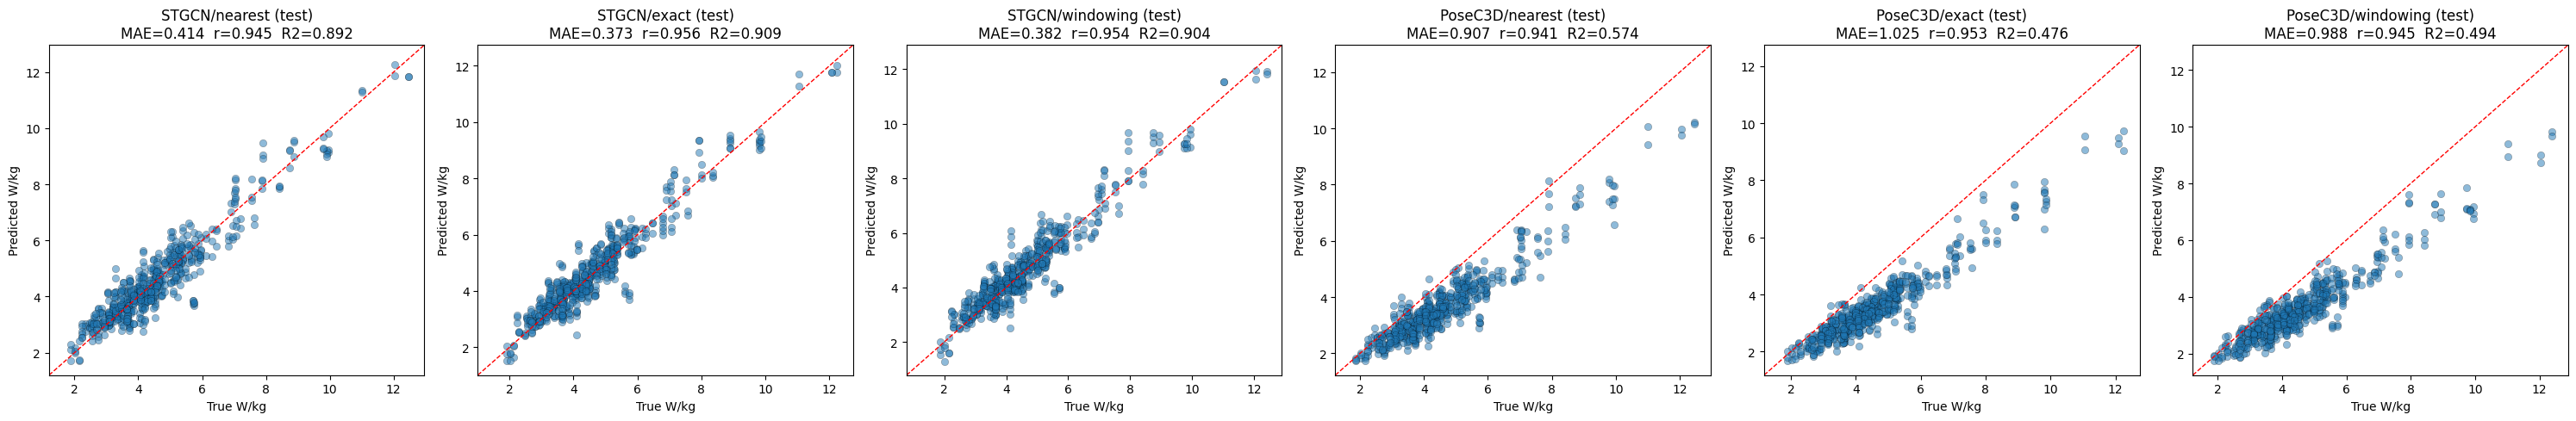

In [6]:
import matplotlib.pyplot as plt

keys = [k for k in cache if k[2] == 'test']
if keys:
    fig, axes = plt.subplots(1, len(keys), figsize=(5 * len(keys), 5), squeeze=False)
    for ax, k in zip(axes[0], keys):
        p, y = cache[k]
        m = metrics(p, y)
        ax.scatter(y, p, alpha=0.5, edgecolors='k', linewidths=0.3)
        lim = [min(y.min(), p.min()) - 0.5, max(y.max(), p.max()) + 0.5]
        ax.plot(lim, lim, 'r--', linewidth=1)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('True W/kg'); ax.set_ylabel('Predicted W/kg')
        ax.set_title(f'{k[0]}/{k[1]} (test)\nMAE={m["MAE"]:.3f}  r={m["r"]:.3f}  R2={m["R2"]:.3f}')
    plt.tight_layout(); plt.show()